In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

## Loading the data

In [12]:
df = pd.read_csv("C:\\Hari\\Edu\\Teaching\\Visual Path\\phase 3\\Model Training and evaluation\\Student_Marks.csv")
print("Dataset shape", df.shape)

Dataset shape (100, 3)


In [13]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


## Defining X as Input and y as Output

In [14]:
X = df.drop("Marks",axis=1)
print(X)

    number_courses  time_study
0                3       4.508
1                4       0.096
2                4       3.133
3                6       7.909
4                8       7.811
..             ...         ...
95               6       3.561
96               3       0.301
97               4       7.163
98               7       0.309
99               3       6.335

[100 rows x 2 columns]


In [16]:
y = df['Marks']
print(y)

0     19.202
1      7.734
2     13.811
3     53.018
4     55.299
       ...  
95    19.128
96     5.609
97    41.444
98    12.027
99    32.357
Name: Marks, Length: 100, dtype: float64


## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [21]:
X_train.shape, X_test.shape

((80, 2), (20, 2))

In [22]:
y_train.shape, y_test.shape

((80,), (20,))

## Scale the Features

In [23]:
scaler = StandardScaler()
# X_train = scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
X_train_scaled = scaler.fit_transform(X_train)


X_train_scaled

array([[ 0.97226573, -0.41235382],
       [-0.14688907, -0.88339102],
       [ 0.97226573, -1.43293443],
       [ 0.41268833, -0.1246392 ],
       [ 0.41268833,  0.02685655],
       [-0.70646647,  0.15925619],
       [-0.70646647, -1.58909811],
       [-1.26604386, -1.5207765 ],
       [-1.26604386,  0.97105274],
       [-1.26604386,  0.31754167],
       [ 0.97226573, -1.46900484],
       [-0.70646647,  0.37949791],
       [ 1.53184313,  0.98293476],
       [-0.14688907, -1.58230839],
       [ 1.53184313,  1.09751138],
       [ 0.41268833, -0.28589518],
       [-0.70646647,  0.67400225],
       [ 0.41268833, -0.73953371],
       [-1.26604386,  1.55242299],
       [-0.14688907,  0.77839428],
       [-0.14688907,  0.01200402],
       [-1.26604386,  0.08414486],
       [-0.14688907, -0.2001749 ],
       [ 0.41268833, -0.13736994],
       [ 1.53184313,  0.20933042],
       [ 1.53184313,  0.03916292],
       [ 1.53184313, -0.68861077],
       [-1.26604386, -1.05143673],
       [ 0.41268833,

In [59]:
X_test_scaled = scaler.transform(X_test)

In [31]:
print(X_train_scaled[0].max(),X_train_scaled[0].min())
print(X_train_scaled[1].max(),X_train_scaled[1].min())


0.9722657305062061 -0.4123538185384234
-0.14688906719877945 -0.8833910220092541


In [28]:
X_train.max(),X_train.min()

(number_courses    8.000
 time_study        7.909
 dtype: float64,
 number_courses    3.000
 time_study        0.096
 dtype: float64)

In [33]:
import matplotlib.pyplot as plt

(array([13.,  6.,  5.,  8., 10., 10.,  4.,  9.,  5., 10.]),
 array([0.096 , 0.8773, 1.6586, 2.4399, 3.2212, 4.0025, 4.7838, 5.5651,
        6.3464, 7.1277, 7.909 ]),
 <BarContainer object of 10 artists>)

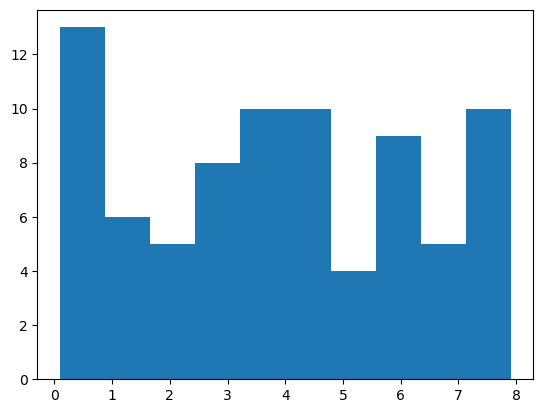

In [ ]:
plt.hist(X_train['time_study'])

In [43]:
import seaborn as sns
import numpy as np

In [46]:
X_train_scaled[0].std(),X_train_scaled[1].std(), X_train.std()

(0.6923097745223148,
 0.36825097740523727,
 number_courses    1.798338
 time_study        2.371369
 dtype: float64)

In [52]:
X_train_scaled[1].std()

0.36825097740523727

<Axes: ylabel='Density'>

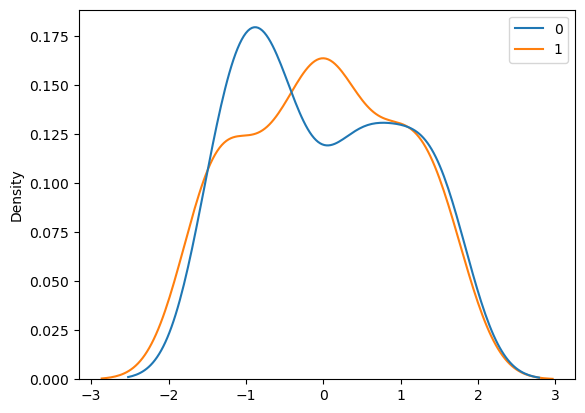

In [58]:
sns.kdeplot(X_train_scaled,color='blue')

<Axes: ylabel='Density'>

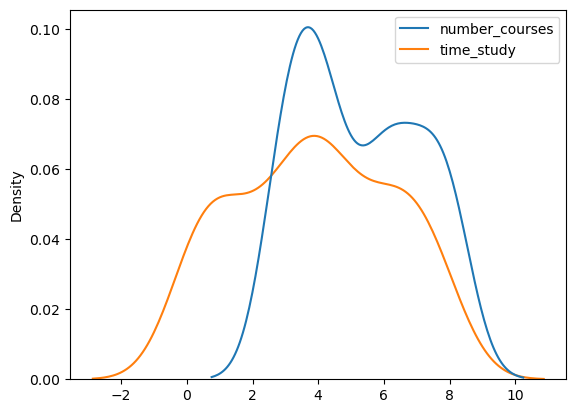

In [56]:
sns.kdeplot(X_train,color='red')

## Training the Model

In [62]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

y = mx1+mx2+c


In [63]:
y_pred = model.predict(X_test_scaled)

## Evaluation metrics

In [64]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [65]:
print(mse,mae,r2)

14.20072613637459 3.079345229666689 0.9459936100591212


## Checking the predicted values using graph

<Axes: ylabel='Marks'>

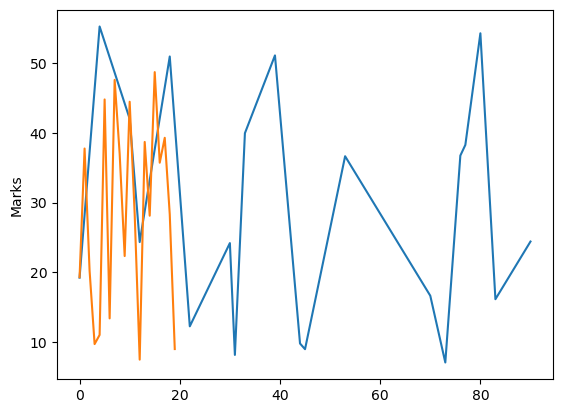

In [74]:
sns.lineplot(y_test)
sns.lineplot(y_pred)


<Axes: >

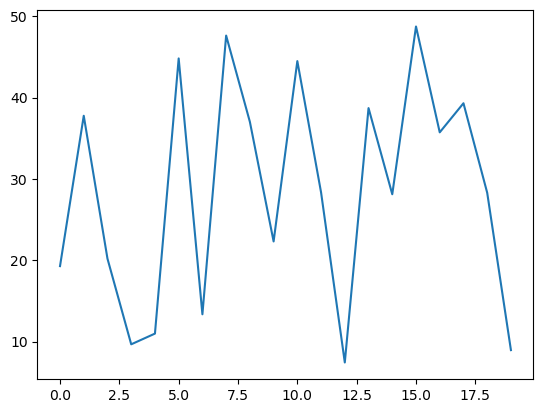

In [70]:
sns.lineplot(y_pred)

## Dump the result to pickle file

In [75]:
joblib.dump(model,"model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [77]:
mdl = joblib.load("model.pkl")

In [79]:
X_test

,number_courses,time_study
83,5,3.197
53,7,6.049
70,4,3.736
45,3,2.061
44,4,1.954
39,6,7.775
22,5,2.051
80,7,7.957
10,3,7.353
0,3,4.508


In [ ]:
5	3.197

In [80]:
scl = joblib.load("scaler.pkl")

## Test the result manually

In [89]:
tst = X_test[:1]

In [90]:
tst["number_courses"]= 7
tst["time_study"]= 9

C:\Users\harry\AppData\Local\Temp\ipykernel_33744\1205616281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tst["number_courses"]= 7
C:\Users\harry\AppData\Local\Temp\ipykernel_33744\1205616281.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tst["time_study"]= 9


In [91]:
tst

,number_courses,time_study
83,7,9


In [92]:
tst_scaled = scl.transform(tst)

In [93]:
tst_scaled

array([[0.97226573, 2.17071236]])

In [94]:
mdl.predict(tst_scaled)

array([53.01664834])